In [55]:
import pgeocode
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import requests
import numpy as np
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
from geopy.geocoders import Nominatim

In [3]:
df = pd.read_csv('complaints_in_just_2025.csv')
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-01-09,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,MOUNTAIN AMERICA FEDERAL CREDIT UNION,AZ,85301,NaN,Web,2025-01-27,Closed with explanation,Yes,11454251
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648
4,2025-05-05,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,MOHELA,OH,44224,NaN,Web,2025-05-05,Closed with explanation,No,13330457


In [4]:
#Add year column
df['Year'] = pd.to_datetime(df['Date received']).dt.year

In [5]:
#Check df shape
print(f'Dataframe has shape of {df.shape}')

Dataframe has shape of (5443005, 17)


Convert ZIP code to longitude and latitude

In [6]:
nomi = pgeocode.Nominatim('us')

#replace X with 0 to get general location
df['ZIP code'] = df['ZIP code'].fillna('').str.replace('X', '0', regex=False)
unique_zips = df['ZIP code'].unique()
result = nomi.query_postal_code(unique_zips)

zip_to_lat = dict(zip(result['postal_code'], result['latitude']))
zip_to_lon = dict(zip(result['postal_code'], result['longitude']))

df['Latitude'] = df['ZIP code'].map(zip_to_lat)
df['Longitude'] = df['ZIP code'].map(zip_to_lon)

print(f"Geocoded {df['Latitude'].notna().sum():,} / {len(df):,} rows successfully")
df[['ZIP code', 'Latitude', 'Longitude']].head(10)

Geocoded 5,060,000 / 5,443,005 rows successfully


,ZIP code,Latitude,Longitude
0,85301,33.5311,-112.1767
1,68100,NaN,NaN
2,35007,33.1934,-86.7944
3,43110,39.8349,-82.8044
4,44224,41.1748,-81.4380
5,53226,43.0493,-88.0414
6,80020,39.9245,-105.0609
7,48228,42.3547,-83.2168
8,90066,34.0030,-118.4298
9,53211,43.0820,-87.8895


Add population for each state

In [7]:
url_2019 = "https://www2.census.gov/programs-surveys/popest/datasets/2010-2019/national/totals/nst-est2019-alldata.csv"
url_2025 = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/state/totals/NST-EST2025-ALLDATA.csv"

df19 = pd.read_csv(url_2019)
df25 = pd.read_csv(url_2025)

#Remove territories
df19 = df19[df19['SUMLEV'] == 40]
df25 = df25[df25['SUMLEV'] == 40]
df25.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,RDOMESTICMIG2021,RDOMESTICMIG2022,RDOMESTICMIG2023,RDOMESTICMIG2024,RDOMESTICMIG2025,RNETMIG2021,RNETMIG2022,RNETMIG2023,RNETMIG2024,RNETMIG2025
14,40,3,6,1,Alabama,5025437,5032962,5050058,5076868,5117850,...,5.116523,5.474119,5.841064,4.854242,4.510946,5.475145,7.131285,8.317052,9.153863,6.238616
15,40,4,9,2,Alaska,733383,732906,734590,733659,734654,...,-4.147200,-8.049043,-6.692034,-5.686549,-6.140560,-2.957419,-5.357402,-3.511513,-2.141122,-3.482138
16,40,4,8,4,Arizona,7158104,7186647,7274022,7370065,7452073,...,11.649945,9.330046,4.696219,4.571144,4.098354,12.758608,12.973291,10.059412,12.665625,7.816213
17,40,3,7,5,Arkansas,3011530,3014399,3027127,3047429,3069856,...,5.368842,6.118307,5.827749,4.514805,4.661182,5.815087,8.099357,7.656011,8.810666,6.422610
18,40,4,9,6,California,39555703,39527808,39152927,39125347,39181667,...,-11.966309,-8.792478,-8.783147,-6.152055,-5.820040,-10.844764,-3.320973,-1.322436,1.811667,-3.043671


In [8]:
cols_2025 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2020, 2026)]
cols_2019 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2011, 2020)]

df19 = df19[cols_2019]
df25 = df25[cols_2025]
df25.head()

pop_df = pd.merge(df19, df25, how='left', on ='NAME')
pop_df.columns = ['State'] + list(np.arange(2011,2026))
pop_df.head()

,State,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Alabama,4799069,4815588,4830081,4841799,4852347,4863525,4874486,4887681,4903185,5032962,5050058,5076868,5117850,5163055,5193088
1,Alaska,722128,730443,737068,736283,737498,741456,739700,735139,731545,732906,734590,733659,734654,736537,737270
2,Arizona,6472643,6554978,6632764,6730413,6829676,6941072,7044008,7158024,7278717,7186647,7274022,7370065,7452073,7556424,7623818
3,Arkansas,2940667,2952164,2959400,2967392,2978048,2989918,3001345,3009733,3017804,3014399,3027127,3047429,3069856,3096080,3114791
4,California,37638369,37948800,38260787,38596972,38918045,39167117,39358497,39461588,39512223,39527808,39152927,39125347,39181667,39364774,39355309


In [9]:
#Add abbreviated state names
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

melted = pop_df.melt(id_vars=  'State', var_name = 'Year', value_name='Population')
melted['State_abrr'] = melted['State'].map(state_abbr)
melted = melted.drop('State', axis = 1)
melted

,Year,Population,State_abrr
0,2011,4799069,AL
1,2011,722128,AK
2,2011,6472643,AZ
3,2011,2940667,AR
4,2011,37638369,CA
...,...,...,...
775,2025,8001020,WA
776,2025,1766147,WV
777,2025,5972787,WI
778,2025,588753,WY


In [10]:
map_df = df.copy()

unique_issues = map_df['Issue'].dropna().unique().tolist()

min_year = int(map_df['Year'].min()) 
max_year = int(map_df['Year'].max())
def interactive_map(issues, year):
    # Filter the df
    to_plot = map_df[(map_df['Year'] == year) & (map_df['Issue'].isin(issues))]
    
    # Check if the filtered dataframe is empty before plotting
    if to_plot.empty:
        print("No data available for the selected filters.")
        return
        
    fig = px.scatter_map(
        # sample at most 1000 points to avoid crashing if there are too many
        to_plot.sample(min(1000, len(to_plot))),
        lat='Latitude',
        lon='Longitude',
        hover_name='Sub-issue',
        color='Issue',
        zoom=3.5,
        center={"lat": 39, "lon": -98},  # Center on US
        map_style='carto-positron',
        height=600,
        width = 1200
    )    
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title=f"Complaints Map in {year}")
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.show()

issues_widget = widgets.SelectMultiple(
    options=unique_issues,
    value=unique_issues[:3],  # Select first 3 by default
    description='Issues',
    disabled=False,
    rows=15,                  # Make it taller so it fills the space nicely next to the map
)
year_widget = widgets.IntSlider(
    value=max_year,
    min=min_year,
    max=max_year,
    step=1,
    description='Year',
    continuous_update=False 
)
# 2. Link the function to the widgets without automatically displaying everything yet
out = widgets.interactive_output(interactive_map, {'issues': issues_widget, 'year': year_widget})
# 3. Create the Layout structure
# Left side gets the year slider and the map output stacked vertically
left_column = widgets.HBox([year_widget, out])
# The main UI puts the left column and the issues widget next to each other horizontally
ui = widgets.HBox([left_column, issues_widget])
# 4. Display the final layout
display(ui)

Interactive Visualization for Complaints

In [11]:
def plot_top_states(year):
    #Filter the dataframe for the selected year
    df_filtered = df[df['Year'] == year]
    
    #Group by State and count complaints for that year
    state_count = df_filtered.groupby('State')['Complaint ID'].count().reset_index(name='Complaint Counts')
    state_count = state_count.sort_values(by='Complaint Counts', ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=state_count.iloc[:10],
        y='State',
        x='Complaint Counts',
        legend=False
    )
    plt.title(f'Top 10 States With Most Complaints in {year}')
    plt.xlabel('Complaint Counts')
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()


available_years = sorted(df['Year'].dropna().unique().astype(int))
# 4. Create the interactive dropdown widget
interact(plot_top_states, year=widgets.IntSlider(value=available_years[0],
    min = available_years[0],
    max = available_years[-1], description='Select Year:'))

interactive(children=(IntSlider(value=2025, description='Select Year:', max=2025, min=2025), Output()), _dom_c…

<function __main__.plot_top_states(year)>

In [12]:
state_count = df.groupby(['Sub-product'])['Complaint ID'].count().reset_index(name='Complaint Counts')
state_count = state_count.sort_values(by='Complaint Counts', ascending=False)
state_count

,Sub-product,Complaint Counts
7,Credit reporting,4792219
20,I do not know,154408
15,General-purpose credit card or charge card,80557
3,Checking account,70235
9,Domestic (US) money transfer,57854
33,Other debt,44945
5,Credit card debt,38636
24,Loan,18104
34,Other personal consumer report,18095
13,Federal student loan servicing,17731


In [13]:
def plot_top_complaints(year):
    #Filter the dataframe for the selected year
    df_filtered = df[df['Year'] == year]
    
    #Group by State and count complaints for that year
    product_count = df_filtered.groupby(['Product'])['Complaint ID'].count().reset_index(name='Complaint Counts')
    product_count = product_count.sort_values(by='Complaint Counts', ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=product_count.iloc[:10],
        y='Product',
        x='Complaint Counts',
        legend=False
    )
    plt.title(f'Top 10 Complaints in {year}')
    plt.xlabel('Complaint Counts')
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()


available_years = sorted(df['Year'].dropna().unique().astype(int))
# 4. Create the interactive dropdown widget
interact(plot_top_complaints, year=widgets.IntSlider(value=available_years[0],
    min = available_years[0],
    max = available_years[-1], description='Select Year:'))


interactive(children=(IntSlider(value=2025, description='Select Year:', max=2025, min=2025), Output()), _dom_c…

<function __main__.plot_top_complaints(year)>

In [14]:
melted.head()

,Year,Population,State_abrr
0,2011,4799069,AL
1,2011,722128,AK
2,2011,6472643,AZ
3,2011,2940667,AR
4,2011,37638369,CA


In [15]:
# Convert to datetime and extract Year-Month for animation
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year-Month'] = df['Date received'].dt.to_period('W').astype(str)
# Group by month and state
monthly_state_counts = df.groupby(['Year','Year-Month', 'State']).size().reset_index(name='Complaints')
monthly_state_counts = monthly_state_counts.sort_values('Year-Month')
monthly_state_counts=monthly_state_counts.merge(melted, 
                        how = 'left', 
                        left_on=['Year','State'],
                        right_on=['Year','State_abrr']
                        )
monthly_state_counts = monthly_state_counts.dropna(subset='Population')
monthly_state_counts['Complaints per 100k'] = monthly_state_counts['Complaints']/monthly_state_counts['Population'] * 100000


monthly_state_counts

,Year,Year-Month,State,Complaints,Population,State_abrr,Complaints per 100k
1,2025,2024-12-30/2025-01-05,ND,16,799358.0,ND,2.001606
2,2025,2024-12-30/2025-01-05,NE,92,2018006.0,NE,4.558956
3,2025,2024-12-30/2025-01-05,NH,42,1415342.0,NH,2.967481
4,2025,2024-12-30/2025-01-05,NJ,1571,9548215.0,NJ,16.453337
5,2025,2024-12-30/2025-01-05,NM,70,2125498.0,NM,3.293346
...,...,...,...,...,...,...,...
3029,2025,2025-12-29/2026-01-04,MD,1081,6265347.0,MD,17.253633
3030,2025,2025-12-29/2026-01-04,ME,35,1414874.0,ME,2.473719
3031,2025,2025-12-29/2026-01-04,MI,1060,10127884.0,MI,10.466155
3032,2025,2025-12-29/2026-01-04,FL,6618,23462518.0,FL,28.206691


In [16]:
fig = px.choropleth(
    monthly_state_counts,
    locations='State',
    locationmode="USA-states",
    color='Complaints per 100k',
    animation_frame='Year-Month',  # Animates map month-by-month
    scope="usa",
    color_continuous_scale="Reds",
    title="Monthly Complaint Trends in 2025"
)
fig.show()

plot complaints per capita to balance out complaints total

Get data from US census

In [20]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,Year,Latitude,Longitude,Year-Month
0,2025-01-09,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,MOUNTAIN AMERICA FEDERAL CREDIT UNION,AZ,85301,NaN,Web,2025-01-27,Closed with explanation,Yes,11454251,2025,33.5311,-112.1767,2025-01-06/2025-01-12
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,68100,NaN,Web,2025-04-08,Closed with explanation,No,12856469,2025,NaN,NaN,2025-04-07/2025-04-13
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708,2025,33.1934,-86.7944,2025-04-14/2025-04-20
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648,2025,39.8349,-82.8044,2025-04-14/2025-04-20
4,2025-05-05,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,MOHELA,OH,44224,NaN,Web,2025-05-05,Closed with explanation,No,13330457,2025,41.1748,-81.4380,2025-05-05/2025-05-11


Time series analysis

In [38]:
ts_df = df.groupby('Date week')['Complaint ID'].count().reset_index(name = 'Complaints')
ts_df['Date week'] = pd.to_datetime(ts_df['Date week'])
ts_df.head()

,Date week,Complaints
0,2024-12-30,45823
1,2025-01-06,87224
2,2025-01-13,141179
3,2025-01-20,117800
4,2025-01-27,99160


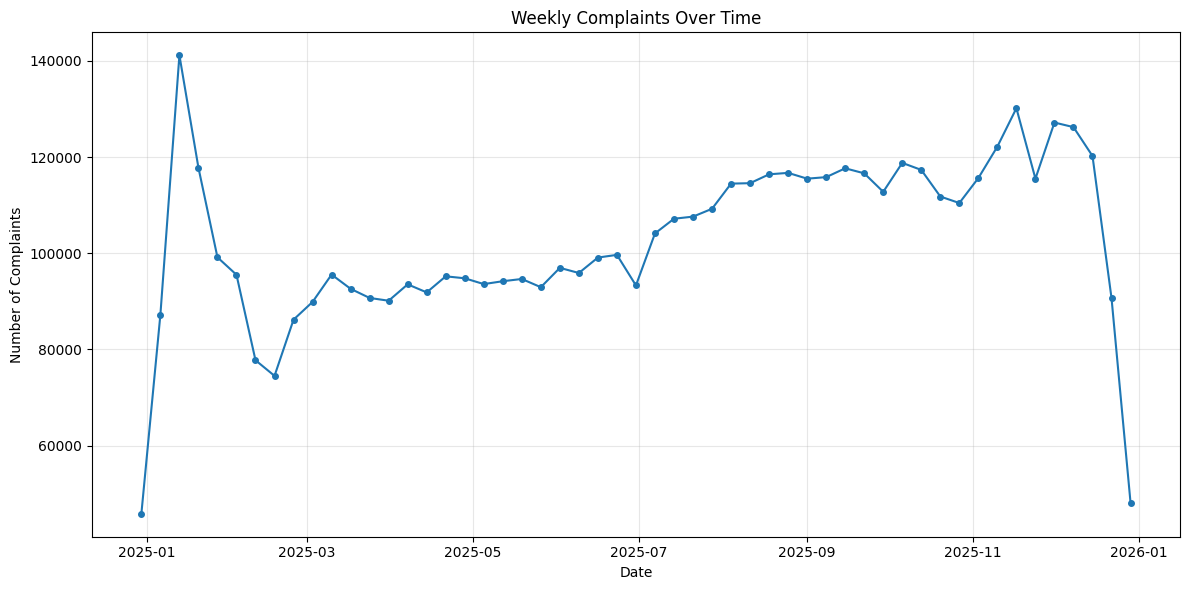

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(ts_df['Date week'], ts_df['Complaints'], marker='o', linestyle='-', markersize=4)
plt.title('Weekly Complaints Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Yooniversity 2.0\AppData\Local\Temp\ipykernel_18600\3301582049.py:5: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



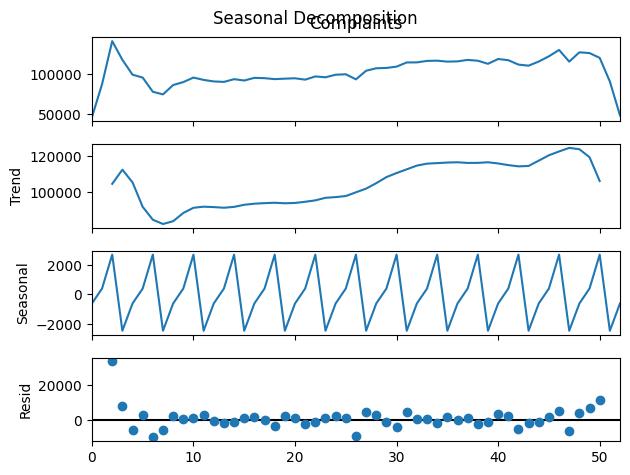

In [57]:
#change period = 52 when running with 2+ years of data
decomp = seasonal_decompose(ts_df['Complaints'], model = 'additive', period = 4)
fig = decomp.plot()
fig.suptitle('Seasonal Decomposition')
fig.show()

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning:

invalid value encountered in divide



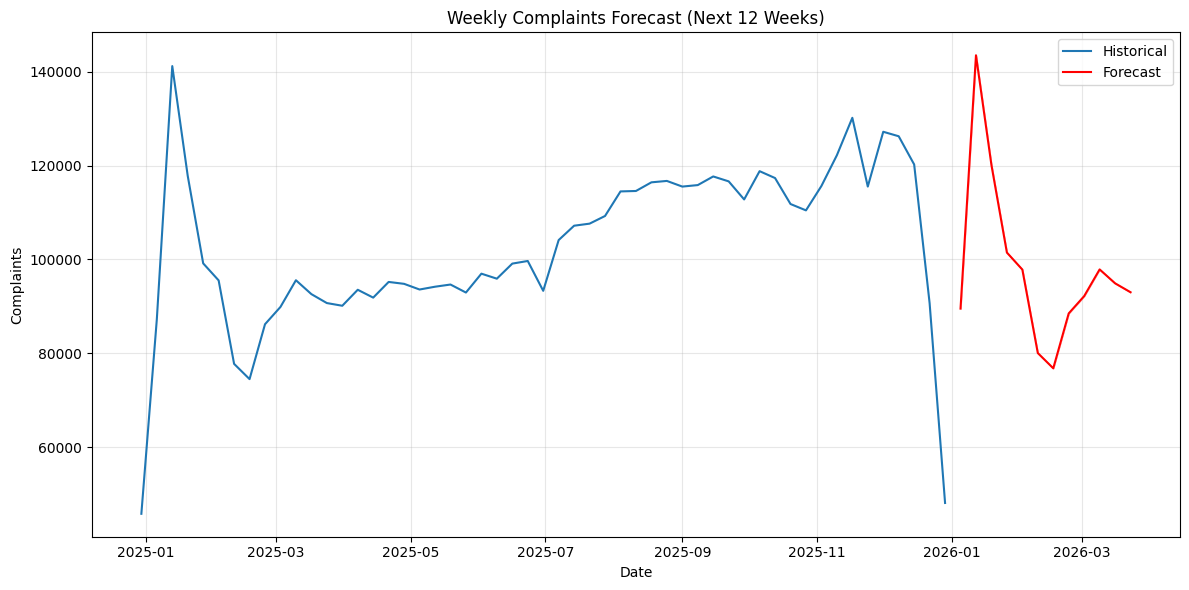

In [59]:
model = SARIMAX(ts_df['Complaints'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
results = model.fit(disp=False)

# Forecast the next 12 weeks
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

forecast_idx = []
for day in range(1, forecast_steps +1):
    forecast_idx.append(ts_df['Date week'].max() + timedelta(weeks = day))

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(ts_df['Date week'], ts_df['Complaints'], label='Historical')
plt.plot(forecast_idx, forecast.predicted_mean.values, color='red', label='Forecast')
plt.fill_between(forecast_idx, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2)
plt.title('Weekly Complaints Forecast (Next 12 Weeks)')
plt.xlabel('Date')
plt.ylabel('Complaints')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
ts_df['Date week'].max()

Timestamp('2025-12-29 00:00:00')